In [68]:
!pip install google-cloud-bigquery pandas

In [69]:
from google.colab import auth
auth.authenticate_user()

In [70]:
from google.cloud import bigquery
import pandas as pd


client = bigquery.Client(
    project="mis-dashboard-app",
    location="asia-south1"
)

query = """
SELECT *
FROM `mis_demo.software_mis_table_final`
"""

df = client.query(query).to_dataframe()

df.head()

,Date,Client_ID,Client_Name,Industry,Country,Product,Subscription_Type,Users_Count,Monthly_Recurring_Revenue,One_Time_Revenue,...,Avg_Response_Time_Hours,Feature_Usage_Score,Contract_Length_Months,Renewal_Status,Sales_Rep,Lead_Source,Payment_Delay_Days,Marketing_Spend,Demo_Completed,Region
0,2026-03-25,C084,Nu4Sys,Education,India,Support Desk,Monthly,72,1950,500,...,36,40,3,Not Renewed,Meena,Cold Call,15,1000,False,South
1,2026-01-04,C004,DeltaSys,Education,India,Support Desk,Monthly,50,1500,500,...,36,40,3,Not Renewed,Meena,Cold Call,15,1000,False,South
2,2026-06-23,C174,Eta8Sys,Education,India,Support Desk,Monthly,95,2800,500,...,36,40,3,Not Renewed,Meena,Cold Call,15,1000,False,South
3,2026-05-04,C124,Epsilon6Sys,Education,India,Support Desk,Monthly,82,2300,500,...,36,40,3,Not Renewed,Meena,Cold Call,15,1000,False,South
4,2026-01-14,C014,XiSys,Education,India,Support Desk,Monthly,55,1600,500,...,36,40,3,Not Renewed,Meena,Cold Call,15,1000,False,South


In [71]:
df.describe()

,Users_Count,Monthly_Recurring_Revenue,One_Time_Revenue,Discount_Percent,Churn_Risk_Score,Customer_Satisfaction_Score,Support_Tickets,Avg_Response_Time_Hours,Feature_Usage_Score,Contract_Length_Months,Payment_Delay_Days,Marketing_Spend
count,200.0,190.0,200.0,200.0,200.000000,200.0,200.0,200.0,200.0,200.0,200.0,200.0
mean,146.855,4885.526316,738.5,6.8,0.450000,7.0,6.8,21.0,64.7,10.2,5.8,2490.0
std,57.761196,2129.58214,669.784147,4.803684,0.186208,1.417762,3.034144,9.404372,13.99246,6.478414,4.907179,1073.621589
min,50.0,1500.0,0.0,0.0,0.200000,5.0,3.0,10.0,40.0,3.0,0.0,1000.0
25%,98.0,3200.0,0.0,3.0,0.300000,6.0,4.0,12.0,55.0,6.0,2.0,2000.0
50%,140.0,4325.0,650.0,6.5,0.450000,7.0,6.5,19.0,67.5,9.0,4.0,2350.0
75%,186.25,6400.0,1200.0,10.0,0.600000,8.0,9.0,30.0,75.0,12.0,10.0,3000.0
max,300.0,9900.0,2100.0,15.0,0.700000,9.0,12.0,36.0,85.0,24.0,15.0,5000.0


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         200 non-null    dbdate 
 1   Client_ID                    200 non-null    object 
 2   Client_Name                  200 non-null    object 
 3   Industry                     200 non-null    object 
 4   Country                      200 non-null    object 
 5   Product                      200 non-null    object 
 6   Subscription_Type            200 non-null    object 
 7   Users_Count                  200 non-null    Int64  
 8   Monthly_Recurring_Revenue    190 non-null    Int64  
 9   One_Time_Revenue             200 non-null    Int64  
 10  Discount_Percent             200 non-null    Int64  
 11  Churn_Risk_Score             200 non-null    float64
 12  Customer_Satisfaction_Score  200 non-null    Int64  
 13  Support_Tickets     

In [73]:
df.isnull().sum()

,0
Date,0
Client_ID,0
Client_Name,0
Industry,0
Country,0
Product,0
Subscription_Type,0
Users_Count,0
Monthly_Recurring_Revenue,10
One_Time_Revenue,0


In [74]:
# Rows with actual values (for training)
train_df = df[df['Monthly_Recurring_Revenue'].notna()]

# Rows with missing values (for future prediction)
future_df = df[df['Monthly_Recurring_Revenue'].isna()]

In [75]:
X_train = train_df[['Users_Count',
                    'Contract_Length_Months',
                    'Feature_Usage_Score',
                    'Discount_Percent',
                    'One_Time_Revenue']]

y_train = train_df['Monthly_Recurring_Revenue']

In [76]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [77]:
model.fit(X_train, y_train)

LinearRegression()

In [78]:
y_train_pred = model.predict(X_train)

In [79]:
train_df = train_df.copy()
train_df['Predicted_MRR'] = y_train_pred

In [80]:
train_df[['Date','Monthly_Recurring_Revenue', 'Predicted_MRR']].head()

,Date,Monthly_Recurring_Revenue,Predicted_MRR
0,2026-03-25,1950,2203.523436
1,2026-01-04,1500,1809.920407
2,2026-06-23,2800,2615.017513
3,2026-05-04,2300,2382.433904
4,2026-01-14,1600,1899.375641


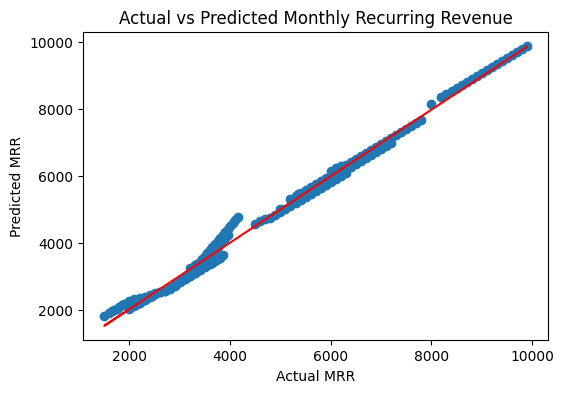

In [81]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# scatter
plt.scatter(train_df['Monthly_Recurring_Revenue'], train_df['Predicted_MRR'])

# regression line
x = train_df['Monthly_Recurring_Revenue']
y = train_df['Predicted_MRR']

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

plt.xlabel("Actual MRR")
plt.ylabel("Predicted MRR")
plt.title("Actual vs Predicted Monthly Recurring Revenue")
plt.show()

In [82]:
X_future = future_df[['Users_Count',
                      'Contract_Length_Months',
                      'Feature_Usage_Score',
                      'Discount_Percent',
                      'One_Time_Revenue']]

future_df = future_df.copy()
future_df['Predicted_MRR'] = model.predict(X_future)

future_df[['Date', 'Predicted_MRR']].head(10).sort_values(by='Date')

,Date,Predicted_MRR
159,2026-07-10,7080.492339
72,2026-07-11,4314.512622
183,2026-07-12,9983.447363
13,2026-07-13,2793.927981
113,2026-07-14,7771.703180
85,2026-07-15,4847.279723
130,2026-07-16,6171.145446
51,2026-07-17,3733.568148
161,2026-07-18,6915.012121
22,2026-07-19,3283.871821


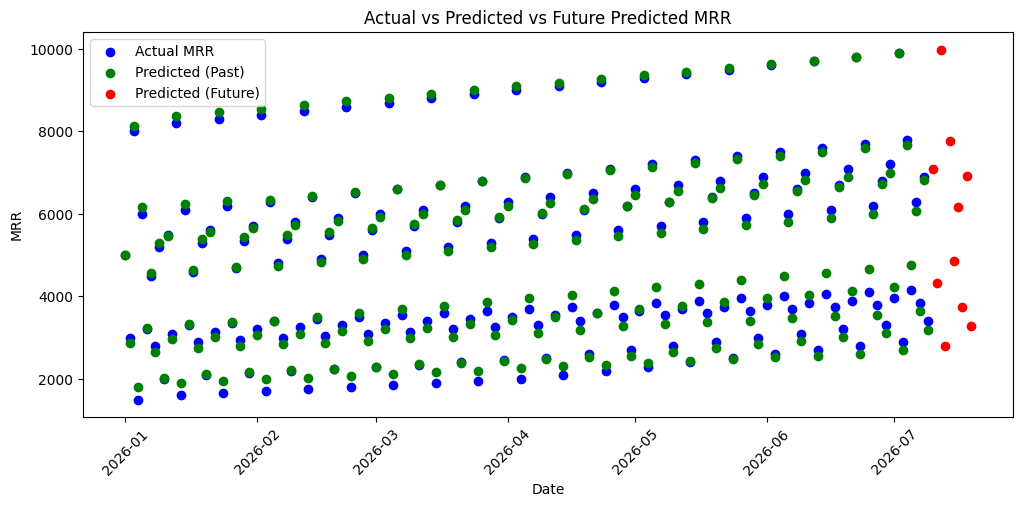

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

# ensure datetime
df['Date'] = pd.to_datetime(df['Date'])

train_df['Date'] = pd.to_datetime(train_df['Date'])
future_df['Date'] = pd.to_datetime(future_df['Date'])

plt.figure(figsize=(12,5))

# actual values
plt.scatter(train_df['Date'], train_df['Monthly_Recurring_Revenue'],
            color='blue', label='Actual MRR')

# predicted on training
plt.scatter(train_df['Date'], train_df['Predicted_MRR'],
            color='green', label='Predicted (Past)')

# future predictions
plt.scatter(future_df['Date'], future_df['Predicted_MRR'],
            color='red', label='Predicted (Future)')

plt.xlabel("Date")
plt.ylabel("MRR")
plt.title("Actual vs Predicted vs Future Predicted MRR")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [84]:
!pip install streamlit pyngrok

In [170]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from google.cloud import bigquery
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score

st.set_page_config(layout="wide")

st.title("Monthly Recurring Revenue Prediction Dashboard")

# BigQuery connection
client = bigquery.Client(project="mis-dashboard-app")

df = client.query("""
SELECT * FROM `mis_demo.software_mis_table_final`
""").to_dataframe()

# preprocessing
df['Date'] = pd.to_datetime(df['Date'])

train_df = df[df['Monthly_Recurring_Revenue'].notna()].copy()
future_df = df[df['Monthly_Recurring_Revenue'].isna()].copy()

features = [
    'Users_Count',
    'Contract_Length_Months',
    'Feature_Usage_Score',
    'Discount_Percent',
    'One_Time_Revenue'
]

# model
model = LinearRegression()
model.fit(train_df[features], train_df['Monthly_Recurring_Revenue'])

train_df['Predicted_MRR'] = model.predict(train_df[features])
future_df['Predicted_MRR'] = model.predict(future_df[features])

y_true = train_df['Monthly_Recurring_Revenue']
y_pred = train_df['Predicted_MRR']

r2 = r2_score(y_true, y_pred)

st.subheader("Model Performance")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(label="R² Score", value=round(r2, 3))

    from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)

with col2:
    st.metric(label="Mean Absolute Error", value=round(mae, 2))

with col3:
    st.metric(label="Data Points", value=len(train_df))

# layout (LEFT = charts, RIGHT = tables)
left_col, right_col = st.columns([1.5,1.5])

# ---------------- LEFT SIDE (CHARTS) ----------------
with left_col:

    st.subheader("Actual vs Predicted vs Future MRR")

    fig, ax = plt.subplots(figsize=(6,3))

    ax.scatter(train_df['Date'], train_df['Monthly_Recurring_Revenue'],
               label='Actual MRR')

    ax.scatter(train_df['Date'], train_df['Predicted_MRR'],
               label='Predicted (Past)')

    ax.scatter(future_df['Date'], future_df['Predicted_MRR'],
               label='Predicted (Future)')

    ax.set_xlabel("Date")
    ax.set_ylabel("MRR")
    ax.set_title("Actual vs Past Predicted vs Future Predicted MRR")
    plt.xticks(rotation=45)
    ax.legend()

    st.pyplot(fig, use_container_width=False)


    st.subheader("Model Fit: Actual vs Predicted")

    fig2, ax2 = plt.subplots(figsize=(6,3))

    ax2.scatter(train_df['Monthly_Recurring_Revenue'],
                train_df['Predicted_MRR'])

    x = train_df['Monthly_Recurring_Revenue']
    y = train_df['Predicted_MRR']

    m, b = np.polyfit(x, y, 1)

    x_sorted = np.sort(x)
    ax2.plot(x_sorted, m*x_sorted + b, color='red')

    ax2.set_xlabel("Actual MRR")
    ax2.set_ylabel("Predicted MRR")
    ax2.set_title("Actual vs Predicted Monthly Recurring Revenue")

    st.pyplot(fig2, use_container_width=False)


# ---------------- RIGHT SIDE (TABLES) ----------------
with right_col:

    st.subheader("Future MRR Predictions for Future Dates")

    future_table = future_df[['Date', 'Predicted_MRR']].sort_values(by='Date').head(10).reset_index(drop = True)

    st.dataframe(future_table)


    st.subheader("Actual vs Past Predicted MRR")

    train_table_preview = train_df[['Date','Monthly_Recurring_Revenue','Predicted_MRR']].sort_values(by='Date').head(10).reset_index(drop = True)

    st.dataframe(train_table_preview)

Overwriting app.py


In [171]:
from pyngrok import ngrok

ngrok.set_auth_token("3G7XKkvVEBZzWgavjzmjbJRNxgb_4wgypBetqVSdn6GBVy3SJ")

In [172]:
ngrok.kill()
!pkill streamlit

In [173]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/log.txt 2>&1 &

In [174]:
import time
time.sleep(5)

In [175]:
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://decay-plot-heroics.ngrok-free.dev" -> "http://localhost:8501"
